### Importing Libraries

In [1]:
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

In [2]:
writer = SummaryWriter(log_dir="runs/lenet_experiment")

In [3]:
BATCH_SIZE = 256
RANDOM_SEED = 42
NUM_EPOCHS = 5
DEVICE = 'cuda:0'

In [4]:
lenet_transforms = transforms.Compose([
    transforms.Resize((32, 32)),    
    transforms.ToTensor(),        
    transforms.Normalize((0.1307,), (0.3081,))
])

In [5]:
train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=lenet_transforms
)

test_dataset = datasets.MNIST(
    root='./data', 
    train=False, 
    transform=lenet_transforms
)

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=True)

images, labels = next(iter(train_loader))
print("Image batch dimensions:", images.shape)
print("Image label dimensions:", labels.shape)

Image batch dimensions: torch.Size([256, 1, 32, 32])
Image label dimensions: torch.Size([256])


#### Custom LeCun "SigmoidLike" Activation

$$
\begin{aligned}
x_{i} &= f(a_{i})\\
f(a) &= A \tanh (Sa)
\end{aligned}
$$

In [7]:
class SigmoidLike(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.A = 1.17159
        self.S = 2/3
        
    def forward(self, x):
        return self.A  * torch.tanh(self.S * x)

### Custom C3 Layer


In [8]:
class LeCunC3(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        C3_CONNECTION_MAP = [
            [0,1,2],
            [1,2,3],
            [2,3,4],
            [3,4,5],
            [0,4,5],
            [0,1,5],
            [0,1,2,3],
            [1,2,3,4],
            [2,3,4,5],
            [0,3,4,5],
            [0,1,4,5],
            [0,1,2,5],
            [0,1,3,4],
            [1,2,4,5],
            [0,2,3,5],
            [0,1,2,3,4,5]
        ]

        self.c3_featuremaps = nn.ModuleList([
            nn.Conv2d(in_channels=len(inputs),out_channels=1, kernel=5)
            for inputs in C3_CONNECTION_MAP
        ])

    def forward(self,x):
        outputs = []
        for conv, input_maps in zip(self.c3_featuremaps, C3_CONNECTION_MAP):
            x_subset = x[:, input_maps, :, :]
            outputs.append(conv(x_subset))

        return outputs

## Model

In [9]:
torch.manual_seed(RANDOM_SEED)
class LeNet5(nn.Module):
    def __init__(self, num_classes, activation = nn.Tanh):
        super().__init__()
        
        self.features = torch.nn.Sequential(
            nn.Conv2d(1,6,5),
            activation(),
            nn.AvgPool2d(2),
            nn.Conv2d(6,16,5),
            activation(),
            nn.AvgPool2d(2),
        )    
        
        self.head = torch.nn.Sequential(
            nn.Conv2d(16,120,5), ## SWAP LATER AND CHECK
            activation(),
            nn.Flatten(),
            nn.Linear(120,84),
            activation(),
            nn.Linear(84,num_classes)
        )

    
    def forward(self, x):
        x = self.features(x)
        logits = self.head(x)
        probas = torch.nn.functional.softmax(input=logits,dim=1)
        return logits, probas

### Model Init

In [10]:
model = LeNet5(num_classes=len(test_loader.dataset.targets.unique()))
model.to(device="cuda")

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (head): Sequential(
    (0): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): Tanh()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [11]:
optim = torch.optim.SGD(model.parameters(),lr=0.1)

## Model Training

In [12]:
for epoch in range(NUM_EPOCHS):
    model.train()
    for batch_idx, (features, targets) in enumerate(train_loader):
       features = features.to(DEVICE)
       targets = targets.to(DEVICE)
       
       #Forward
       logits, probas = model(features)
       cost = nn.functional.cross_entropy(logits, targets)
       
       optim.zero_grad()
       cost.backward()
       
       optim.step()
       
       if batch_idx % 50 == 0:
          print(f"Epoch : {epoch+1} | Batch: {batch_idx} | Cost: {cost}")
          global_step = epoch * len(train_loader) + batch_idx
          writer.add_scalar("Loss/train", cost.item(), global_step)
            
        
    model.eval()
    with torch.inference_mode():
        correct_pred, num_examples = 0, 0
        for batch_idx, (features, targets) in enumerate(train_loader):
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)
            
            logits, probas = model(features)
            pred = torch.argmax(probas,1)
            
            num_examples += targets.size(0)
            correct_pred += (pred == targets).sum()
            
            accuracy = correct_pred.float()/num_examples * 100
            writer.add_scalar("Accuracy/train", accuracy, epoch)

            
        
writer.close()

Epoch : 1 | Batch: 0 | Cost: 2.3037967681884766
Epoch : 1 | Batch: 50 | Cost: 0.9877188801765442
Epoch : 1 | Batch: 100 | Cost: 0.6358646154403687
Epoch : 1 | Batch: 150 | Cost: 0.3004128336906433
Epoch : 1 | Batch: 200 | Cost: 0.38887080550193787
Epoch : 2 | Batch: 0 | Cost: 0.27781617641448975
Epoch : 2 | Batch: 50 | Cost: 0.255962610244751
Epoch : 2 | Batch: 100 | Cost: 0.2867046594619751
Epoch : 2 | Batch: 150 | Cost: 0.17617523670196533
Epoch : 2 | Batch: 200 | Cost: 0.221166729927063
Epoch : 3 | Batch: 0 | Cost: 0.2529606223106384
Epoch : 3 | Batch: 50 | Cost: 0.182785302400589
Epoch : 3 | Batch: 100 | Cost: 0.16917851567268372
Epoch : 3 | Batch: 150 | Cost: 0.1291390359401703
Epoch : 3 | Batch: 200 | Cost: 0.19432318210601807
Epoch : 4 | Batch: 0 | Cost: 0.11811680346727371
Epoch : 4 | Batch: 50 | Cost: 0.13402678072452545
Epoch : 4 | Batch: 100 | Cost: 0.10437817871570587
Epoch : 4 | Batch: 150 | Cost: 0.0910082757472992
Epoch : 4 | Batch: 200 | Cost: 0.08736954629421234
Epoch 

In [13]:
with torch.set_grad_enabled(False):
    with torch.inference_mode():
        correct_pred, num_examples = 0, 0
        for batch_idx, (features, targets) in enumerate(test_loader):
            features = features.to(DEVICE)
            targets = targets.to(DEVICE)
            
            logits, probas = model(features)
            pred = torch.argmax(probas,1)
            
            num_examples += targets.size(0)
            correct_pred += (pred == targets).sum()
            
        print(correct_pred.float()/num_examples * 100)

tensor(97.6500, device='cuda:0')


In [14]:
_, (features,targets) = next(iter(enumerate(test_loader)))

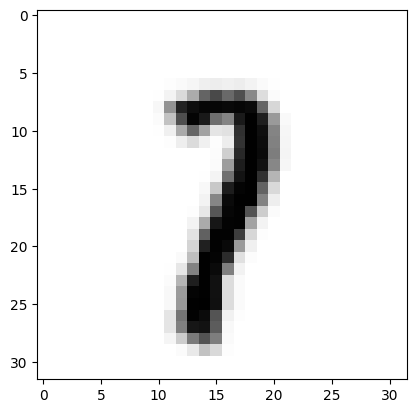

In [15]:
plt.imshow(features[0].squeeze(), cmap='Greys')

In [18]:
model.eval()
logits, probas = model(features.to(DEVICE)[0, None])
print('Probability 3 %.2f%%' % (probas[0][7]*100))

Probability 3 92.97%
